<a href="https://colab.research.google.com/github/syifaymd/Pratikum-Analisis-Deret-Waktu/blob/main/Tugas_Kelompok_7_Minggu_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center> EKSPLORASI DERET WAKTU </center></h1>
KELOMPOK 7 :

1. Nur Jannah Tuasikal (M0501251002)
2. Rismawati Saputri (A2502251012)
3. Syifa Ul Qalbi YMD (M0501251026)
4. Estyaningsi Purnama (M0501251058)

<center>
_____________________________________________________________________________________________________________________________
</center>


## **1. Import Package**

In [56]:
#PACKAAGE
#package PythonTsa
!pip install PythonTsa

# menginstall package pydataset
!pip install pydataset

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from pydataset import data
from statsmodels.datasets import get_rdataset
from pandas.plotting import lag_plot

import warnings
warnings.filterwarnings("ignore")

## **2. Import Data**



In [58]:
link = "https://raw.githubusercontent.com/syifaymd/Pratikum-Analisis-Deret-Waktu/main/Konsumsi%20listrik%20listrik"
nao = pd.read_csv(link, sep=';')

nao.head()

#melihat struktur data
nao.dtypes

,0
periode,object
listrik,float64


**Pemasukan dan Pemeriksaan Awal Data**

In [59]:
# melihat 5 data pertama
nao.head()

,periode,listrik
0,Jan-13,16961.49236
1,Feb-13,17571.04985
2,Mar-13,17362.44422
3,Apr-13,18227.87292
4,May-13,18273.59476


In [60]:
#melihat 5 data terakhir
nao.tail()

,periode,listrik
126,Jul-23,24645.45565
127,Aug-23,25126.35282
128,Sep-23,25433.76944
129,Oct-23,26633.69422
130,Nov-23,26755.41154


In [61]:
#cek missing values
nao.isnull().sum()

,0
periode,0
listrik,0


Berdasarkan hasil tahapan awal pemeriksaan data dapat ditunjukan bahawa pada data konsumsi listrik tidak terdapat nilai amatan yang kosong atau **NA**

#**3. Pembentukan Indeks Waktu**

In [62]:
import numpy as np

In [63]:
print(nao.columns)

Index(['periode', 'listrik'], dtype='object')


In [64]:
print(nao['periode'].head())

0    Jan-13
1    Feb-13
2    Mar-13
3    Apr-13
4    May-13
Name: periode, dtype: object


In [65]:
# Mengubah format string seperti 'Jan-13' menjadi datetime (misal: format '%b-%y' untuk Jan-13)
nao['date'] = pd.to_datetime(nao['periode'], format='%b-%y', errors='coerce')

# Ekstrak tahun dan bulan
nao['year'] = nao['date'].dt.year
nao['month'] = nao['date'].dt.month

# Cek hasilnya
display(nao.head())

,periode,listrik,date,year,month
0,Jan-13,16961.49236,2013-01-01,2013,1
1,Feb-13,17571.04985,2013-02-01,2013,2
2,Mar-13,17362.44422,2013-03-01,2013,3
3,Apr-13,18227.87292,2013-04-01,2013,4
4,May-13,18273.59476,2013-05-01,2013,5


In [66]:
nao.head()

,periode,listrik,date,year,month
0,Jan-13,16961.49236,2013-01-01,2013,1
1,Feb-13,17571.04985,2013-02-01,2013,2
2,Mar-13,17362.44422,2013-03-01,2013,3
3,Apr-13,18227.87292,2013-04-01,2013,4
4,May-13,18273.59476,2013-05-01,2013,5


## **4. Visualisasi dan Identifikasi Pola Deret**

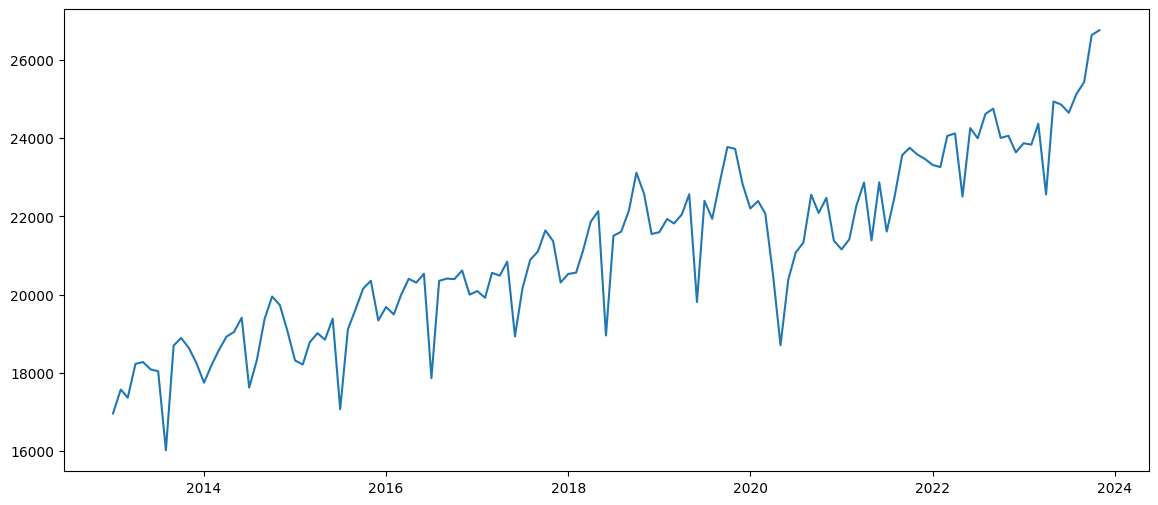

In [67]:
plt.figure(figsize=(14,6))
plt.plot(nao['date'],nao['listrik']); plt.show()

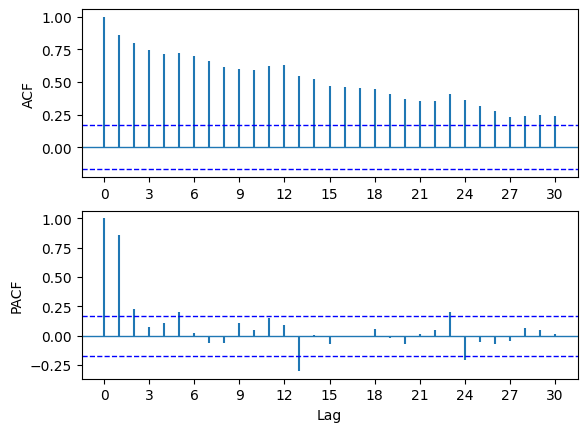

In [68]:
# membuat plot ACF dan PACF contoh dari data nao
acf_pacf_fig(nao['listrik'], both=True, lag=30)

Berdasarkan plot ACF dan PACF yang diperoleh apakah deret stasioner? Mengapa?
<br>
Berdasarkan hasil yang ditunjukan oleh PLOT ACF dan PACF diatas diketahui deret tersebut tidak stasioner, dapat dijelaskan sebagai berikut :
*   Nilai koefisien autokorelasi (ACF) mengalami penurunan (decay) sangat lambat dan bertahap dari lag ke lag (tidak langsung turun mendekati nol dengan cepat). Pola penurunan yang lambat seperti ini merupakan indikator utama bahwa deret waktu tidak stasioner dalam rata-rata (biasanya karena mengandung unsur tren atau unit root).


## **5. Uji Kestasioneran dalam Nilai Tengah**
Selain berdasarkan plot deret, kestasioneran suatu deret dapat diperiksa menggunakan uji statistik, salah satunya adalah uji ADF. Hipotesis yang digunakan dalam uji ADF adalah

$H_0$ menyatakan deret tidak stasioner

$H_1$ menyatakan deret stasioner.

Kriteria keputusan: Tolak $H_0$ jika p-value < 0.05

In [69]:
# uji unit-root Augmented Dickey Fuller
from statsmodels.tsa.stattools import adfuller

adfuller(nao['listrik'])[1]

0.9805463853858516

Bagaimana interpretasi hasil uji tersebut? Apakah interpretasi hasil uji sama dengan interpretasi dari plot deret maupun plot ACF?
<p>
<br>
Karena nilai $p$-value ($0.9805$) jauh lebih besar dari taraf nyata $0.05$, maka kita gagal menolak $H_0$. Artinya, data deret waktu tersebut mengandung unit root, yang berarti data tidak stasioner.</br>
<br> Keterkaitan :

*   Pada plot ACF, penurunan nilai koefisien yang sangat lambat mengindikasikan adanya unsur tren/non-stasioneritas.
*   Hasil uji ADF menghasilkan p-value sebesar 0,9805 > 0,05, sehingga H₀ gagal ditolak. Dengan demikian, deret konsumsi listrik belum stasioner dalam nilai tengah. Hasil ini konsisten dengan plot ACF yang menunjukkan penurunan autokorelasi secara lambat.
</br>
</p>

## **6. Dekomposisi Deret Waktu**

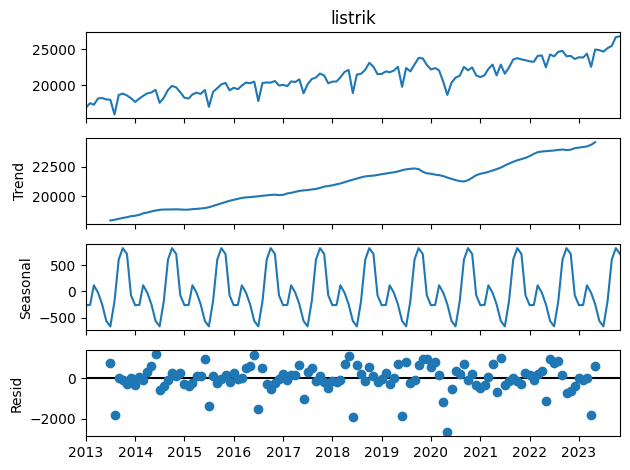

In [70]:
from statsmodels.tsa.seasonal import seasonal_decompose
nao2=nao.set_index('date')
result = seasonal_decompose(nao2['listrik'], model='additive')
result.plot()
plt.show()

**Jika dilihat dari hasil dekomposisi tersebut apa interpretasi Anda? Bagaimana keterkaitan hasil dekomposisi dengan interpretasi Anda dari plot ACF dan uji ADF?**

Hasil dekomposisi menunjukkan adanya tren meningkat pada konsumsi listrik dari tahun 2013 hingga 2023. Selain itu, terdapat pola musiman yang berulang pada periode tahunan. Keberadaan tren menunjukkan bahwa rata-rata deret berubah dari waktu ke waktu sehingga data belum stasioner. Hasil ini konsisten dengan plot ACF dan uji ADF yang sebelumnya menunjukkan adanya ketidakstasioneran.

Selain dekomposisi, pola musiman dan pola antar tahun dapat ditelusuri lebih lanjut menggunakan boxplot.

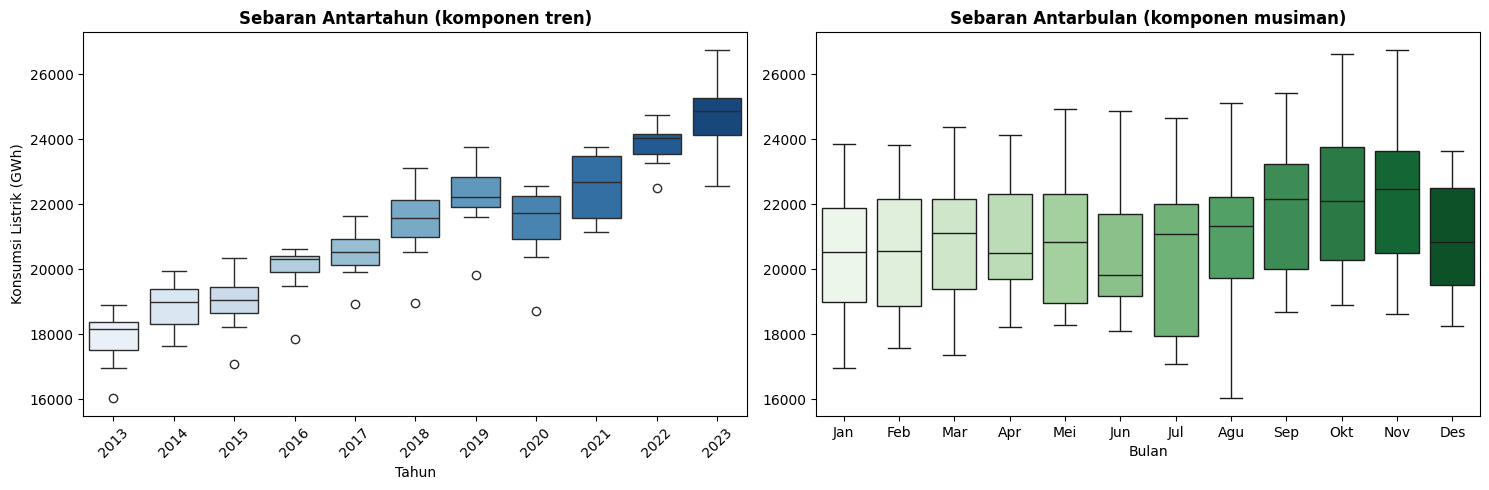

In [71]:
# menyiapkan data untuk boxplot antartahun dan antarbulan
pivot = nao[['year', 'month', 'listrik']].rename(columns={'year': 'tahun', 'month': 'bulan'})
nama_bulan = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=pivot['tahun'], y=pivot['listrik'], ax=ax[0], palette='Blues')
ax[0].set_title('Sebaran Antartahun (komponen tren)', fontweight='bold')
ax[0].set_xlabel('Tahun'); ax[0].set_ylabel('Konsumsi Listrik (GWh)')
ax[0].tick_params(axis='x', rotation=45)

sns.boxplot(x=pivot['bulan'], y=pivot['listrik'], ax=ax[1], palette='Greens')
ax[1].set_title('Sebaran Antarbulan (komponen musiman)', fontweight='bold')
ax[1].set_xlabel('Bulan'); ax[1].set_ylabel('')
ax[1].set_xticklabels(nama_bulan)

plt.tight_layout(); plt.show()

**Interpretasi:** *Boxplot* antartahun menunjukkan kecenderungan median konsumsi listrik yang meningkat dari tahun ke tahun. *Boxplot* antarbulan menunjukkan adanya perbedaan distribusi konsumsi antarbulan, meskipun pola musiman masih dipengaruhi oleh tren jangka panjang.

## **7. Uji Kestasioneran dalam Ragam (Box-Cox)**

**Jika dilihat berdasarkan plot deret apakah deret sudah stasioner dalam ragam?**
<br> Belum tentu / Perlu diperiksa lebih lanjut, namun jika dilihat secara visual dari plot deret utama (paling atas) atau plot residu:</br>



Terdapat dua kestasioneran dalam deret waktu, yaitu kestasioneran dalam nilaitengah dan dalam ragam. Uji ADF hanya digunakan untuk menguji kestasioneran dalam nilaitengah, sementara untuk mengetahui kestasioneran deret dalam ragam dapat dicek melalui uji Boxcox. Jika nilai $\lambda=1$ atau angka 1 masuk dalam interval kepercayaan $\lambda$, maka dapat dikatakan bahwa deret sudah stasioner dalam ragam.

Dalam melakukan transformasi boxcox, perlu diperhatikan bahwa nilai deret harus positif semua. Jika ada nilai deret yang negatif ataupun nol maka deret harus ditransformasi agar nilainya menjadi positif.

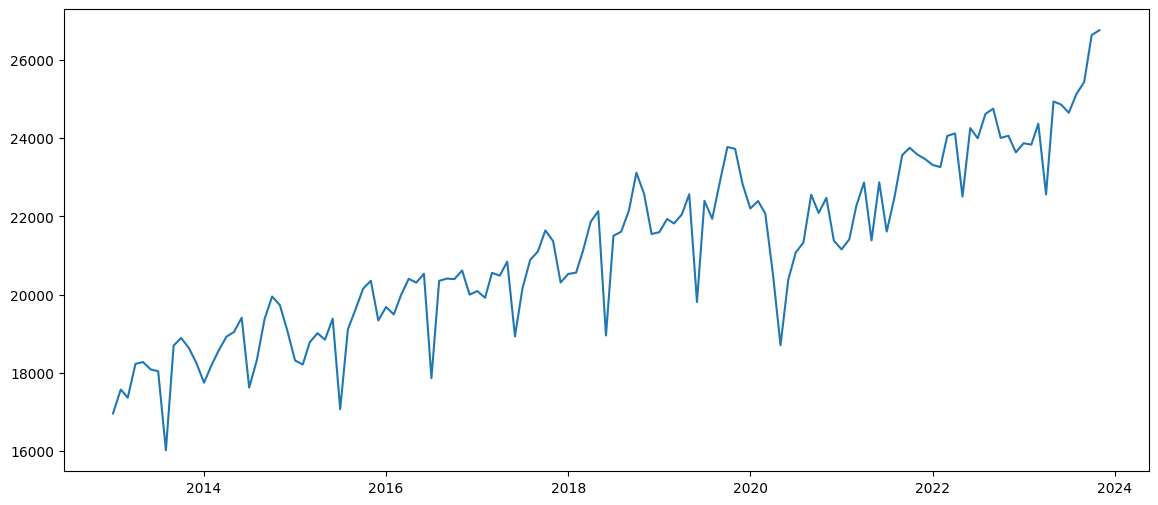

In [72]:
# Plot data baru
plt.figure(figsize=(14,6))
plt.plot(nao['date'],nao['listrik']); plt.show()

In [73]:
from scipy.stats import boxcox,  boxcox_llf
data,lambda_fit,ci=boxcox(nao['listrik'], alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  0.22658243494715655
interval kepercayaan lambda: (-1.3047625013508621, 1.7647730226285725)


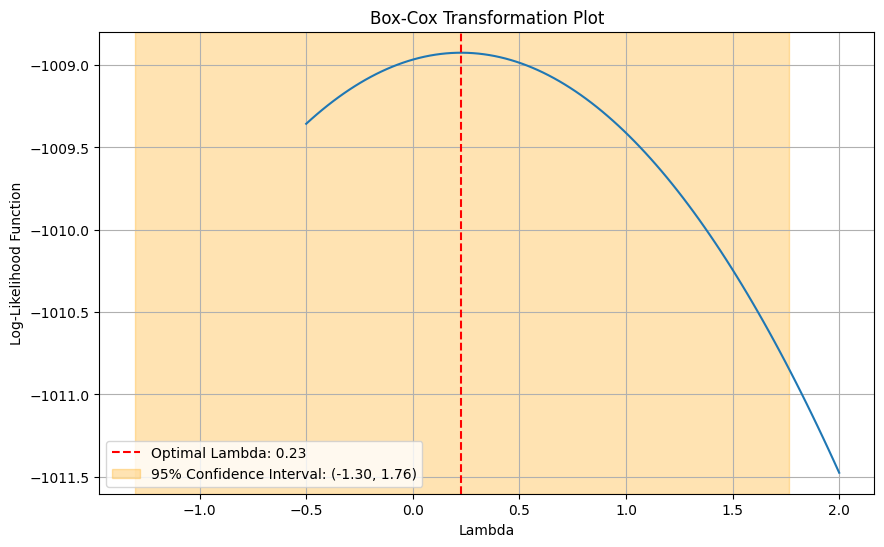

In [74]:
# Generate a range of lambda values
lambdas = np.linspace(-0.5, 2, 100)

# Calculate log-likelihood for each lambda
llf = [boxcox_llf(l, nao['listrik']) for l in lambdas]

plt.figure(figsize=(10, 6))
plt.plot(lambdas, llf)
plt.axvline(lambda_fit, color='r', linestyle='--', label=f'Optimal Lambda: {lambda_fit:.2f}')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.3, label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend(); plt.grid(True); plt.show()

**Bagaimana interpretasi Anda dari nilai lambda yang diperoleh?**
<br>
Berdasarkan hasil transformasi Box-Cox, diperoleh nilai λ optimal sebesar 0,23 dengan interval kepercayaan 95% sebesar -1,30 hingga 1,76. Karena nilai λ = 1 masih berada dalam interval kepercayaan tersebut, tidak terdapat bukti yang cukup bahwa transformasi diperlukan untuk menstabilkan ragam. Oleh karena itu, data asli dapat digunakan tanpa transformasi Box-Cox.</br>

## **8. Penanganan Ketidakstasioneran**
Berdasarkan analisis sebelumnya, deret konsumsi listrik belum stasioner dalam nilai tengah karena adanya tren, tetapi sudah stasioner dalam ragam, sehingga transformasi Box-Cox tidak diperlukan. Oleh karena itu, penanganan difokuskan pada ketidakstasioneran dalam nilai tengah, yaitu melalui pembedaan (*differencing*).

### 8.1 Pembedaan Orde Pertama (Regular Differencing)

Pembedaan orde pertama dilakukan dengan menghitung $Z_t = Y_t - Y_{t-1}$, yang bertujuan menghilangkan komponen tren.

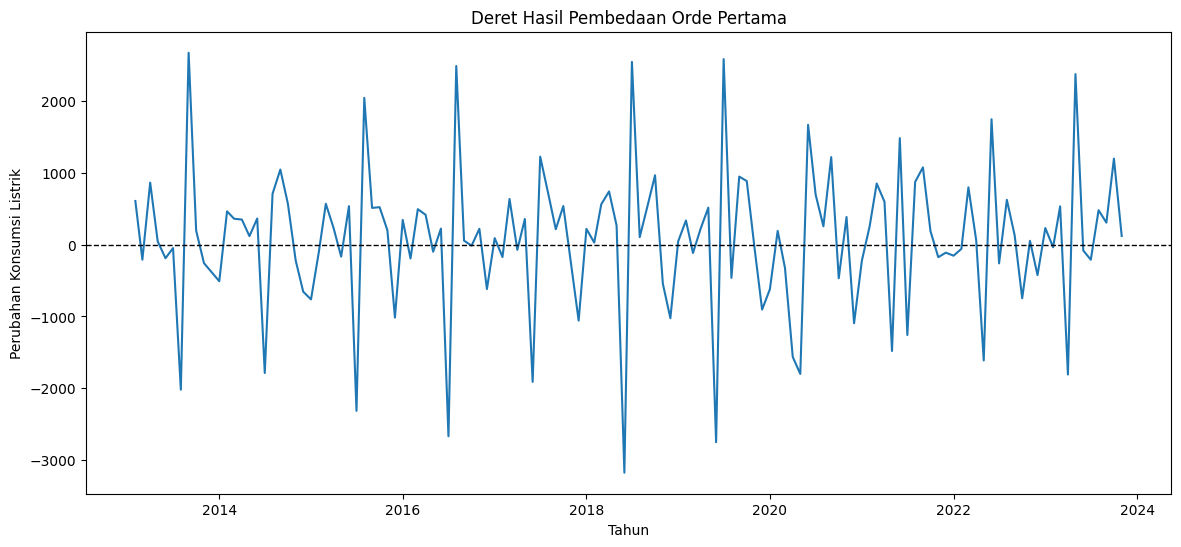

In [75]:
nao_ts = nao.set_index('date')['listrik']

diff1 = nao_ts.diff().dropna()

plt.figure(figsize=(14,6))
plt.plot(diff1)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Deret Hasil Pembedaan Orde Pertama')
plt.xlabel('Tahun'); plt.ylabel('Perubahan Konsumsi Listrik')
plt.show()

In [76]:
# Uji ADF setelah differencing
p_adf_diff1 = adfuller(diff1, autolag='AIC')[1]
p_adf_diff1

0.0028426694370048545

**Interpretasi:**
<br>
Setelah dilakukan differencing orde pertama, deret berfluktuasi di sekitar nilai nol dan tidak menunjukkan tren yang jelas. Hasil uji ADF menghasilkan p-value sebesar 0,00284 < 0,05, sehingga H₀ ditolak. Dengan demikian, deret hasil differencing orde pertama telah stasioner dan diperoleh orde differencing d = 1.
<br>

### 8.2 ACF dan PACF Setelah Pembedaan

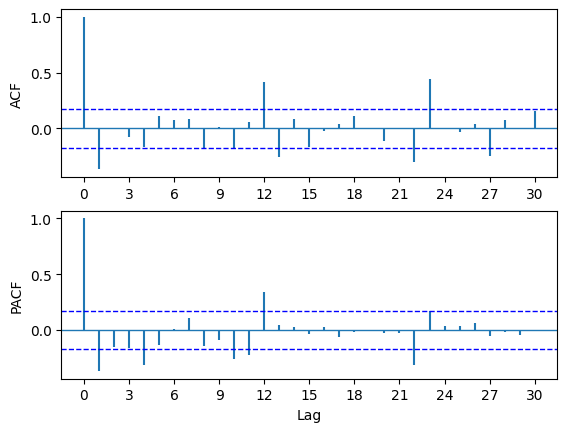

In [77]:
acf_pacf_fig(diff1, both=True, lag=30)

Plot ACF setelah pembedaan menunjukkan peluruhan yang lebih cepat dibandingkan data asli, yang mengindikasikan bahwa komponen tren telah berhasil dihilangkan. Namun, spike signifikan pada lag ke-12 menunjukkan bahwa pola musiman masih terdapat dalam data. Oleh karena itu, analisis dilanjutkan dengan pembedaan musiman.

### 8.3 Pembedaan Musiman (Seasonal Differencing)

Karena dekomposisi menunjukkan adanya pola musiman tahunan (periode 12 bulan), pembedaan musiman $W_t = Z_t - Z_{t-12}$ dapat diterapkan pada deret hasil pembedaan orde pertama untuk memastikan komponen musiman juga tertangani.

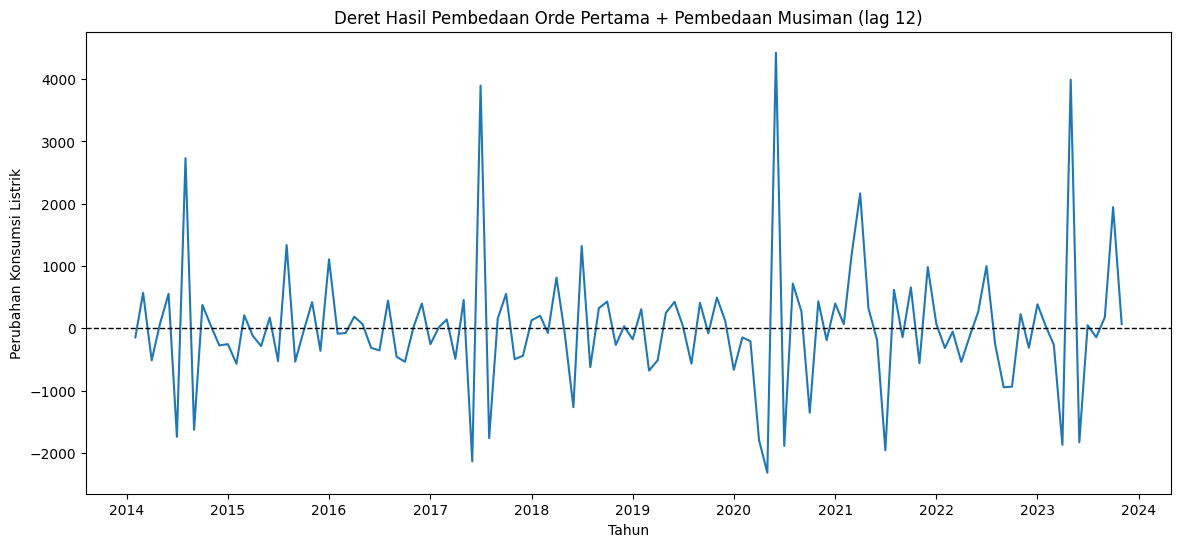

In [78]:
diff_seasonal = diff1.diff(12).dropna()

plt.figure(figsize=(14,6))
plt.plot(diff_seasonal)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Deret Hasil Pembedaan Orde Pertama + Pembedaan Musiman (lag 12)')
plt.xlabel('Tahun'); plt.ylabel('Perubahan Konsumsi Listrik')
plt.show()

In [79]:
# ADF setelah pembedaan orde 1 + musiman
p_adf_diffs = adfuller(diff_seasonal, autolag='AIC')[1]
p_adf_diffs

2.681855602749222e-19

Hasil uji ADF setelah differencing orde pertama dan differencing musiman menghasilkan p-value sebesar $2,68 × 10⁻¹⁹$ < 0,05, sehingga H₀ ditolak. Dengan demikian, deret hasil pembedaan dapat dinyatakan stasioner secara statistik. Hal ini menunjukkan bahwa kombinasi differencing orde pertama dan differencing musiman dengan lag 12 berhasil mengatasi ketidakstasioneran pada deret.

## **9. Lag Plot**

Lag plot adalah plot sederhana antara nilai deret pada waktu $t$ ($Y_t$) dengan nilai deret pada waktu sebelumnya ($Y_{t-k}$). Pola titik yang membentuk garis lurus (positif) menunjukkan adanya autokorelasi yang kuat pada lag tersebut.

### 9.1 Lag Plot pada Data Asli (Lag 1 dan Lag 12)

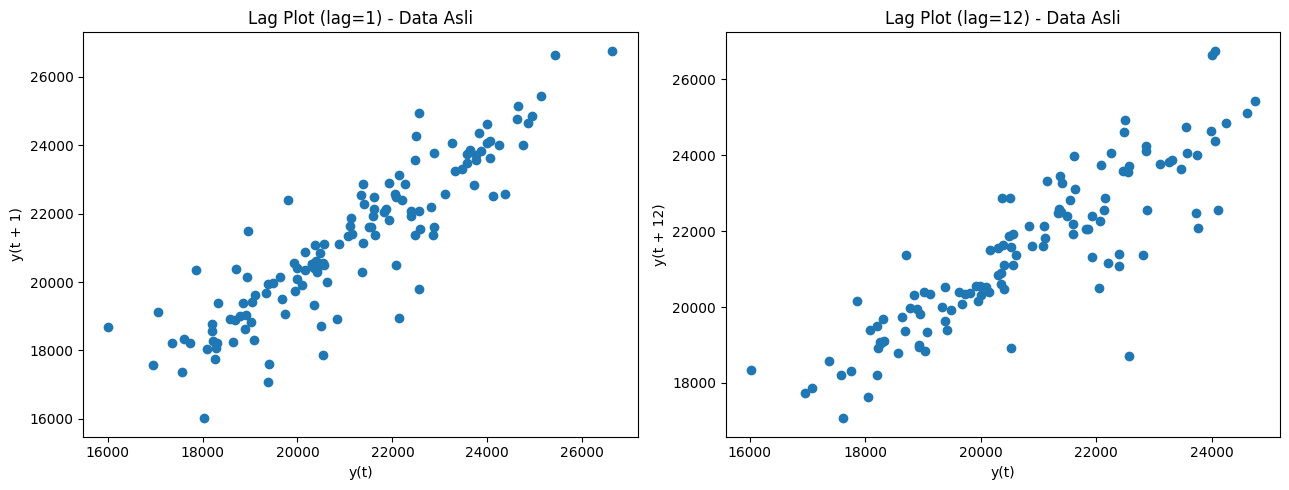

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

lag_plot(nao_ts, lag=1, ax=axes[0])
axes[0].set_title('Lag Plot (lag=1) - Data Asli')

lag_plot(nao_ts, lag=12, ax=axes[1])
axes[1].set_title('Lag Plot (lag=12) - Data Asli')

plt.tight_layout()
plt.show()

**Interpretasi:** Pada lag 1, titik-titik membentuk pola linear positif yang menunjukkan adanya hubungan yang kuat antara nilai pada suatu periode dengan periode sebelumnya. Hal ini konsisten dengan ACF data asli yang menunjukkan autokorelasi tinggi pada lag awal. Pada lag 12, pola hubungan positif mengindikasikan adanya ketergantungan pada periode yang berjarak 12 bulan, yang mendukung dugaan adanya pola musiman tahunan.

### 9.2 Lag Plot Setelah Penanganan Ketidakstasioneran (Lag 1)

Sebagai pembanding, berikut lag plot pada deret yang telah dibedakan. Jika penanganan berhasil, pola titik seharusnya lebih menyebar acak (tidak lagi membentuk garis lurus yang jelas).

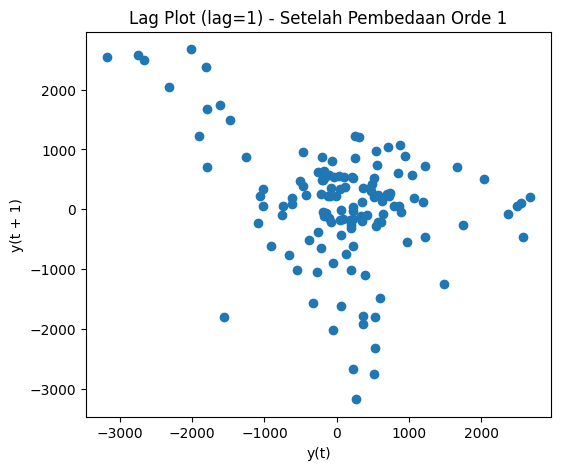

In [81]:
plt.figure(figsize=(6,5))
lag_plot(diff1, lag=1)
plt.title('Lag Plot (lag=1) - Setelah Pembedaan Orde 1')
plt.show()

Sebaran titik yang lebih acak dan tidak lagi membentuk pola linear yang tegas menguatkan kesimpulan pada Bagian 8 bahwa pembedaan orde pertama berhasil menghilangkan sebagian besar struktur autokorelasi yang disebabkan oleh tren.